**STEP 1: Import Required Libraries (EDA)**

In [3]:
# Core libraries
import numpy as np
import pandas as pd


# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Statistics
from scipy import stats


# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

**STEP 2: Load the Data & Initial Checks**

In [4]:
# Load dataset (upload file to Colab first)
df = pd.read_excel('online_course_recommendation.xlsx')


# Shape of dataset
print('Shape:', df.shape)


# First 5 rows
df.head()

Shape: (100000, 14)


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


**2.1 Check Duplicates**

In [5]:
print('Duplicate rows:', df.duplicated().sum())


df = df.drop_duplicates()

Duplicate rows: 0


**2.2 Clean Column Names**

In [6]:
df.columns = (
df.columns
.str.strip()
.str.lower()
.str.replace(' ', '_')
)


print(df.columns)

Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken'],
      dtype='object')


**2.3 Check Missing Values**

In [7]:
print(df.isnull().sum())

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64


**2.4 Impute Missing Values**

In [8]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns


# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns


# Imputation
for col in num_cols:
  df[col].fillna(df[col].median(), inplace=True)


for col in cat_cols:
  df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-2711085874.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2711085874.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

**STEP 3: Statistical Summary (Min, Max, Median, Mode)**

In [9]:
summary = df.describe().T
summary['median'] = df[num_cols].median()
summary['mode'] = df[num_cols].mode().iloc[0]
summary[['min','max','median','mean','mode']]

,min,max,median,mean,mode
user_id,1.000,49999.00,24793.50,24935.663570,37381.00
course_id,1.000,9999.00,5012.00,5006.863560,1139.00
course_duration_hours,5.000,100.00,52.40,52.383540,85.90
rating,1.000,5.00,4.00,3.959859,5.00
enrollment_numbers,50.000,49999.00,25057.50,25052.822850,4227.00
course_price,20.000,500.00,262.31,261.073369,60.89
feedback_score,0.092,1.00,0.75,0.746865,1.00
time_spent_hours,1.000,84.15,19.92,20.691054,1.00
previous_courses_taken,0.000,19.00,5.00,4.992670,5.00


**STEP 4: Separate Numerical & Categorical Columns**

In [10]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


print('Numerical Columns:\n', numerical_columns)
print('\nCategorical Columns:\n', categorical_columns)

Numerical Columns:
 ['user_id', 'course_id', 'course_duration_hours', 'rating', 'enrollment_numbers', 'course_price', 'feedback_score', 'time_spent_hours', 'previous_courses_taken']

Categorical Columns:
 ['course_name', 'instructor', 'certification_offered', 'difficulty_level', 'study_material_available']


**STEP 5: Distribution Analysis (Histogram & Bar Charts)**

**5.1 Numerical Distributions**

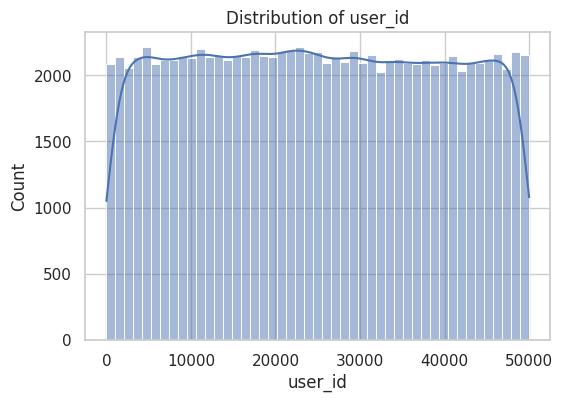

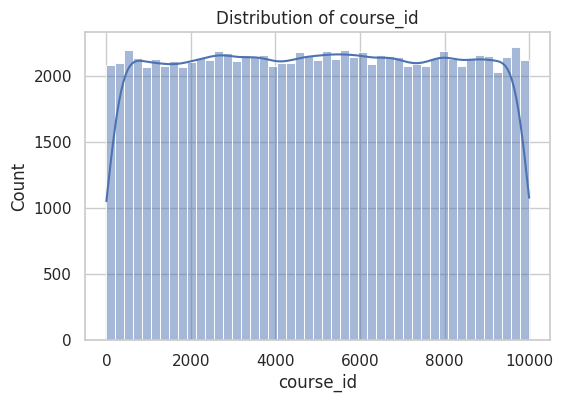

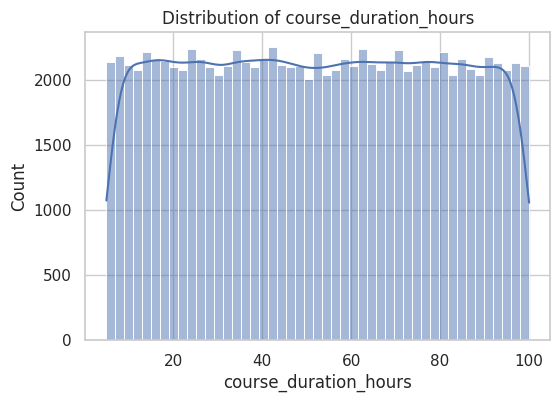

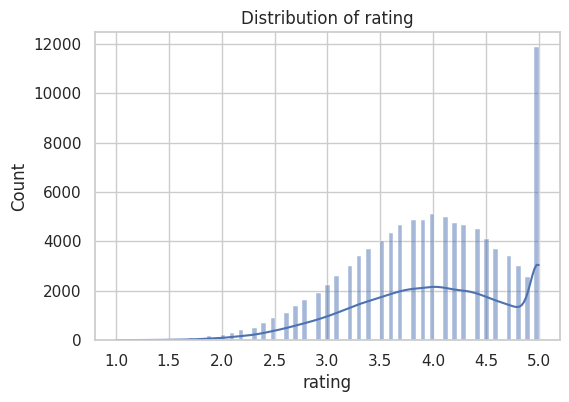

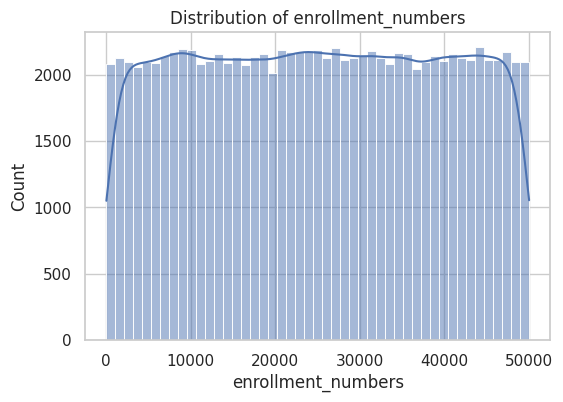

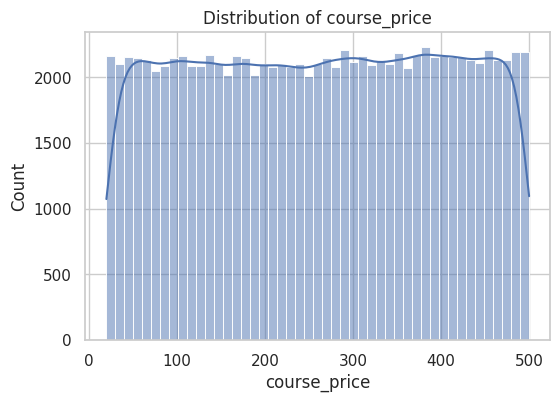

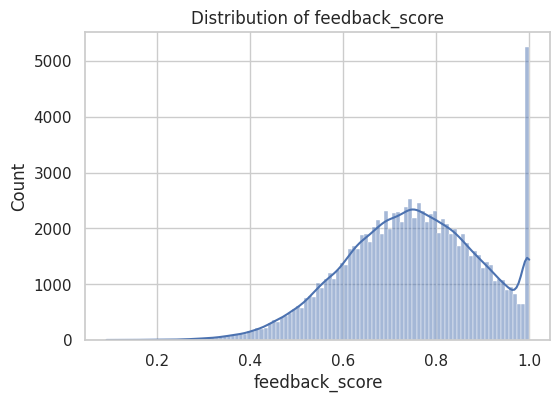

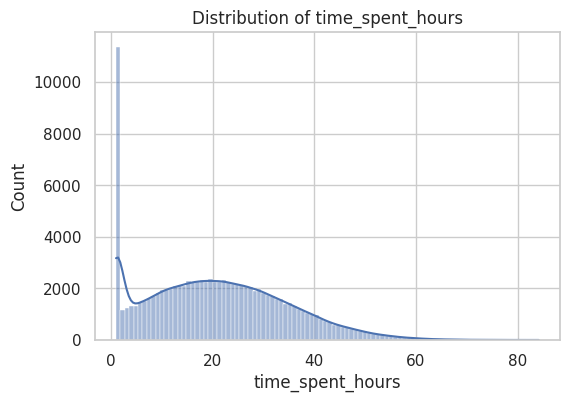

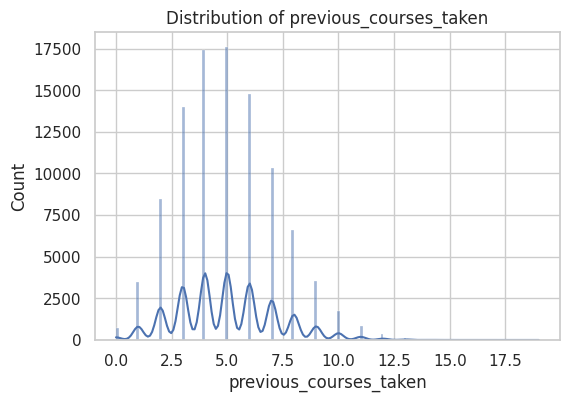

In [11]:
for col in numerical_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()

**5.2 Categorical Distribution & Data Imbalance**

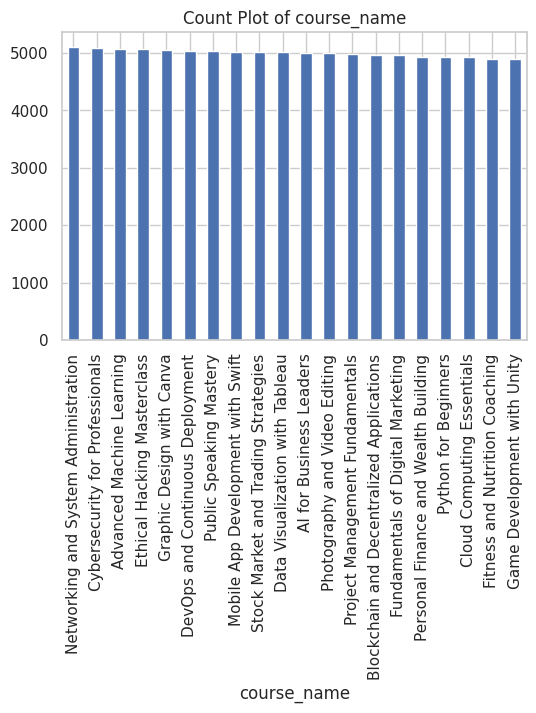

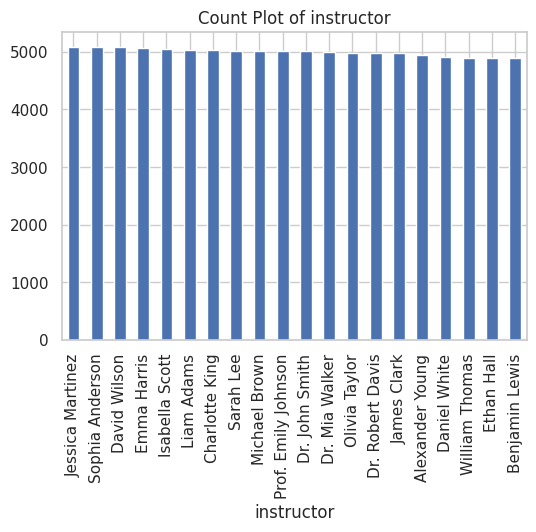

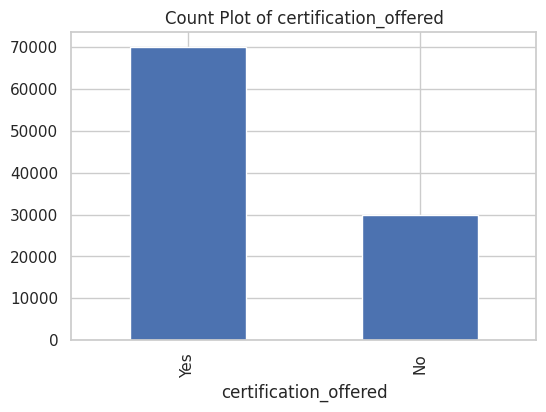

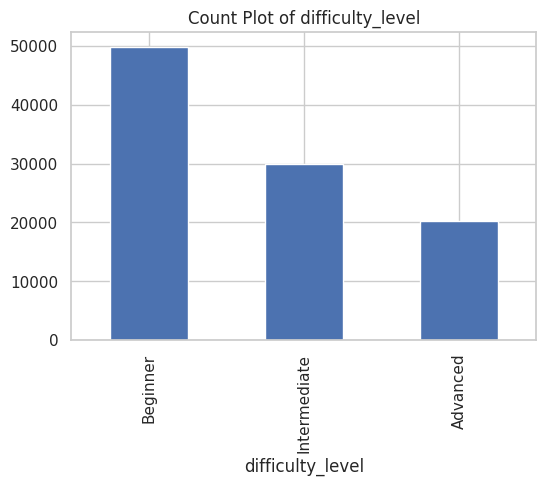

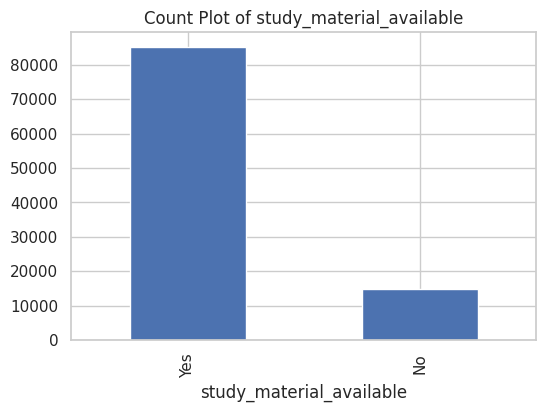

In [12]:
for col in categorical_columns:
  plt.figure(figsize=(6,4))
  df[col].value_counts().plot(kind='bar')
  plt.title(f'Count Plot of {col}')
  plt.show()

**STEP 6: Visualize Categorical Columns (Target Insights)**

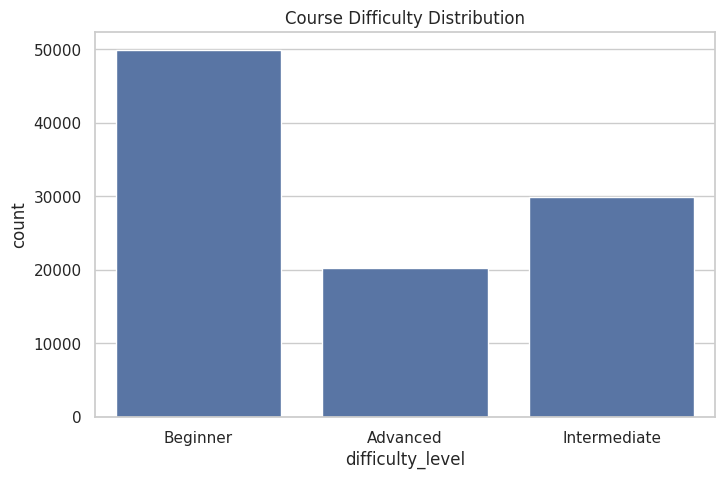

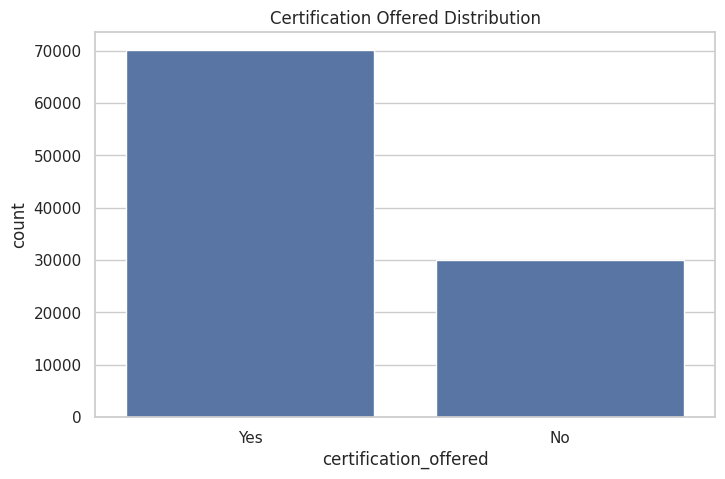

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='difficulty_level')
plt.title('Course Difficulty Distribution')
plt.show()


plt.figure(figsize=(8,5))
sns.countplot(data=df, x='certification_offered')
plt.title('Certification Offered Distribution')
plt.show()

**STEP 7: Outlier Detection & Treatment (IQR Method)**
**7.1 Boxplots with Outliers**

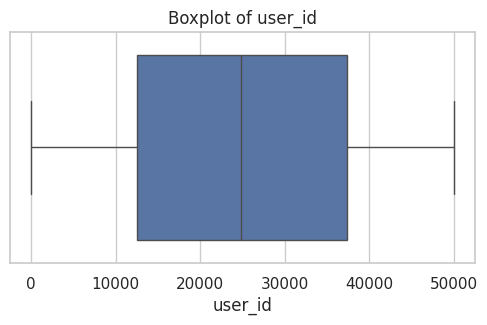

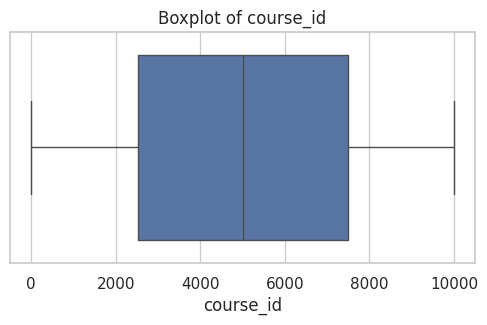

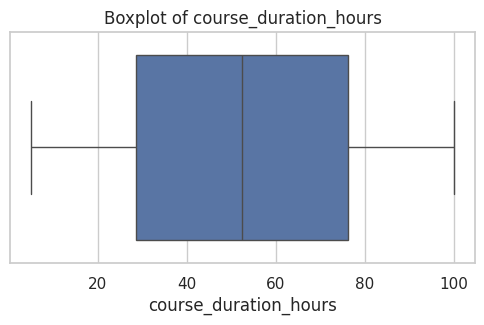

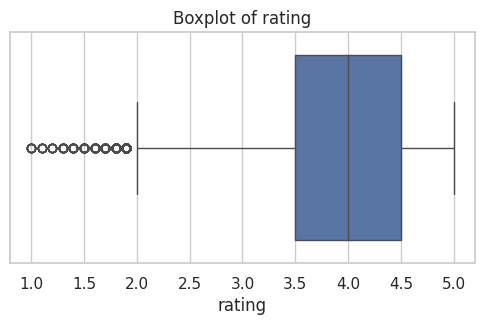

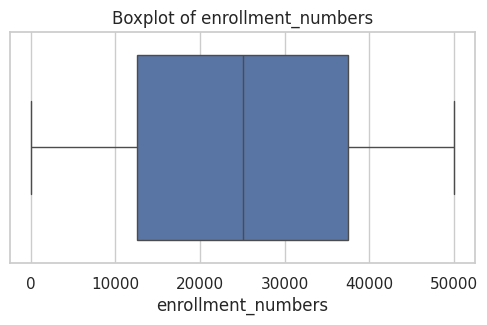

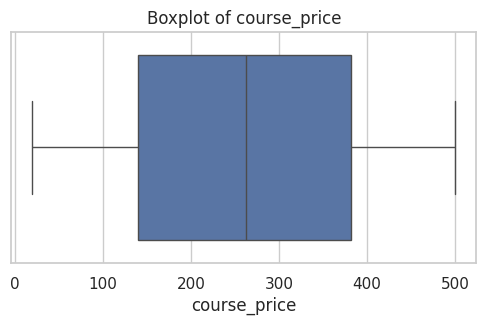

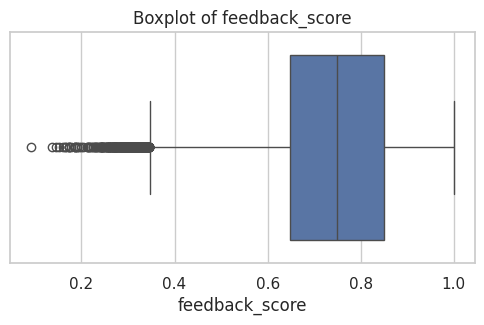

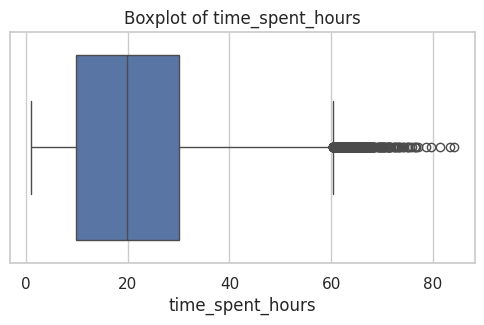

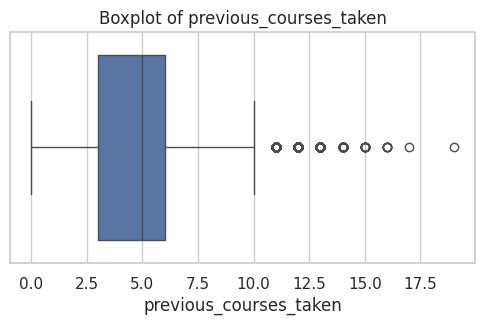

In [14]:
for col in numerical_columns:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.show()

**7.2 Outlier Removal Using IQR**

In [15]:
def remove_outliers_iqr(data, col):
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  return data[(data[col] >= lower) & (data[col] <= upper)]


for col in numerical_columns:
  df = remove_outliers_iqr(df, col)

**7.3 Boxplots After Outlier Treatment**

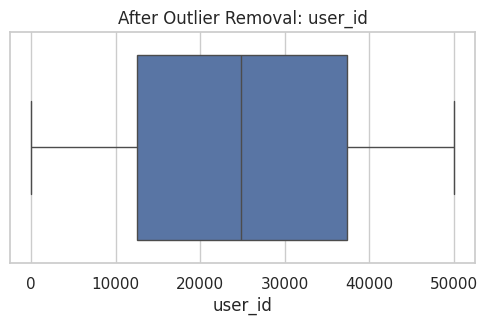

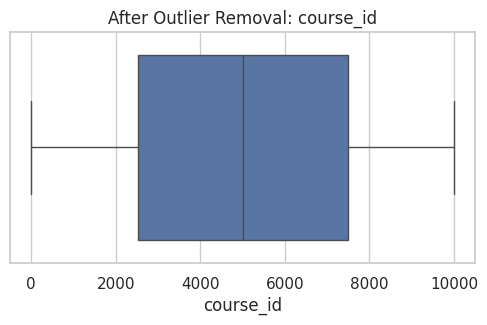

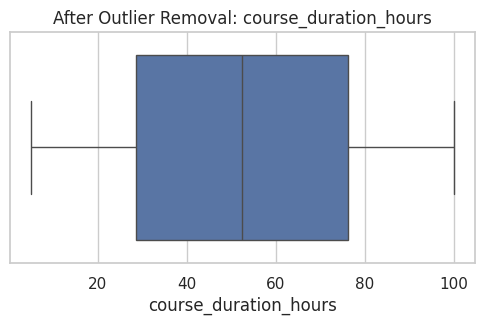

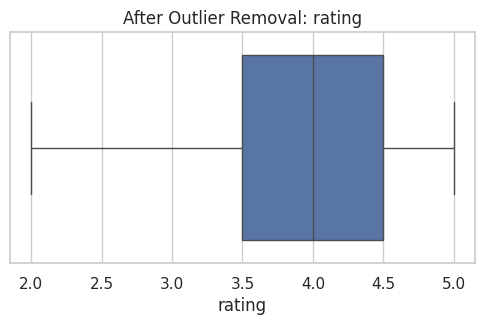

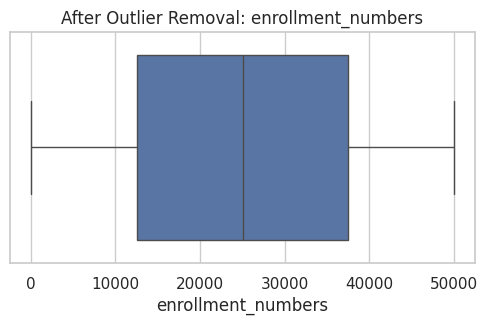

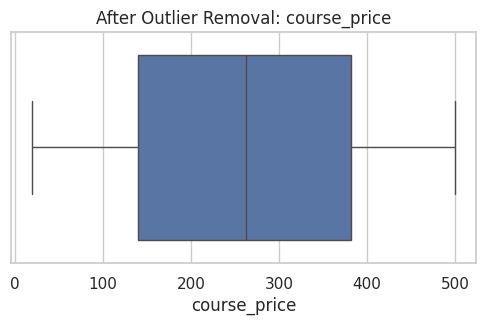

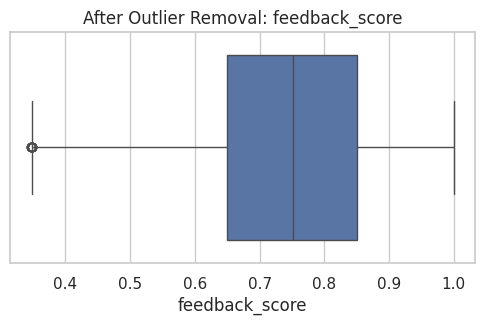

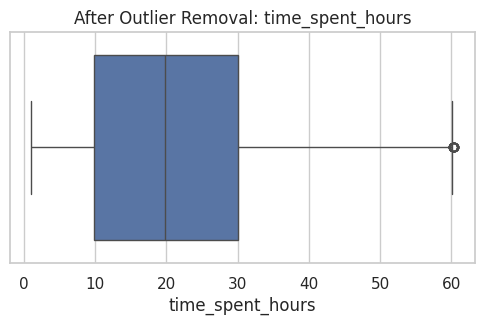

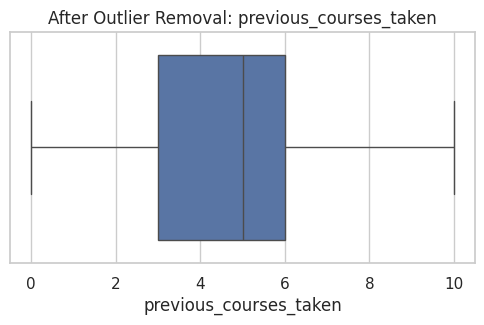

In [16]:
for col in numerical_columns:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[col])
  plt.title(f'After Outlier Removal: {col}')
  plt.show()

**STEP 8: Correlation Heatmap & Highly Correlated Features**

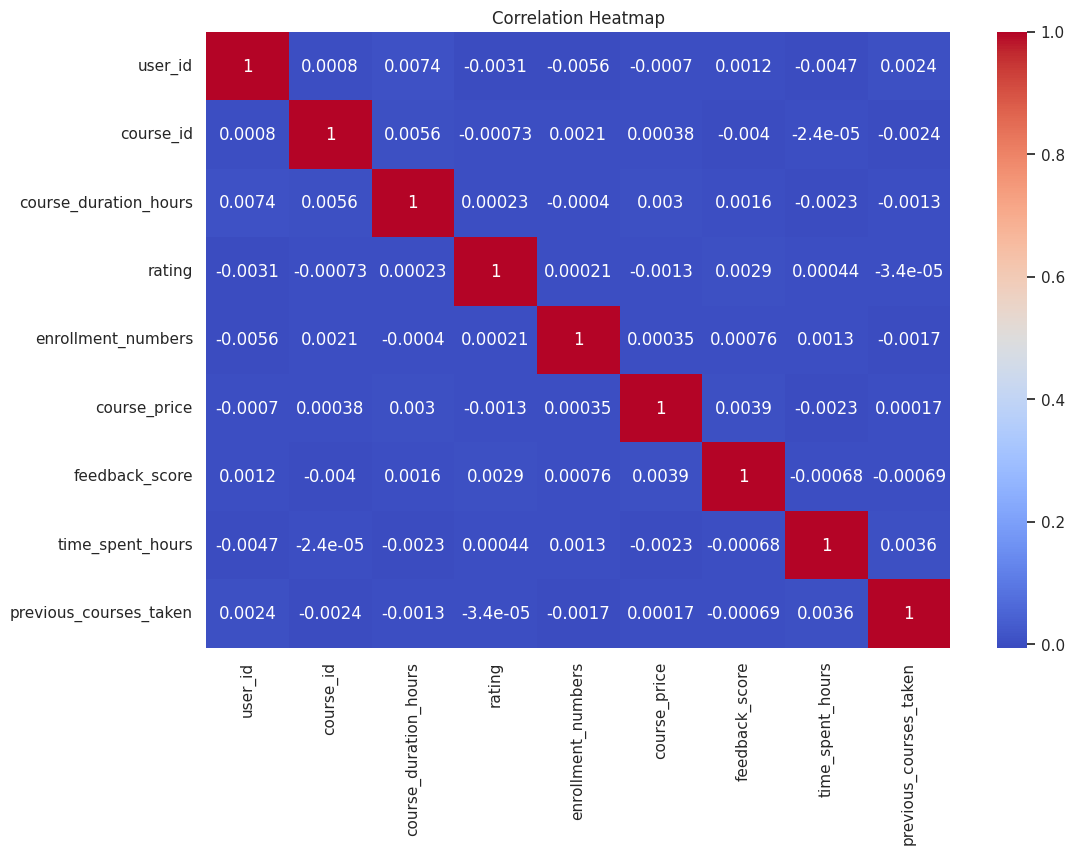

In [17]:
corr_matrix = df[numerical_columns].corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Highly Correlated Pairs (>|0.75|)**

In [18]:
high_corr = (
corr_matrix.abs()
.unstack()
.sort_values(ascending=False)
)


high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.75)]
high_corr

,,0


**STEP 9: Standardization & Encoding (Numerical + Categorical)**

In [19]:
# Preprocessing pipelines
num_pipeline = Pipeline([
('scaler', StandardScaler())
])


cat_pipeline = Pipeline([
('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer([
('num', num_pipeline, numerical_columns),
('cat', cat_pipeline, categorical_columns)
])


X_processed = preprocessor.fit_transform(df)
print('Processed feature shape:', X_processed.shape)


Processed feature shape: (97403, 56)


**STEP 10: Relationship Analysis (Key Factors Affecting Courses)**

**10.1 Rating vs Price**

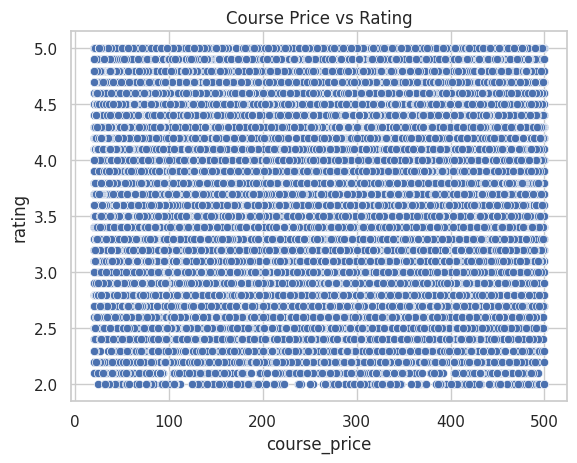

In [20]:
sns.scatterplot(data=df, x='course_price', y='rating')
plt.title('Course Price vs Rating')
plt.show()

**10.2 Enrollment vs Rating**

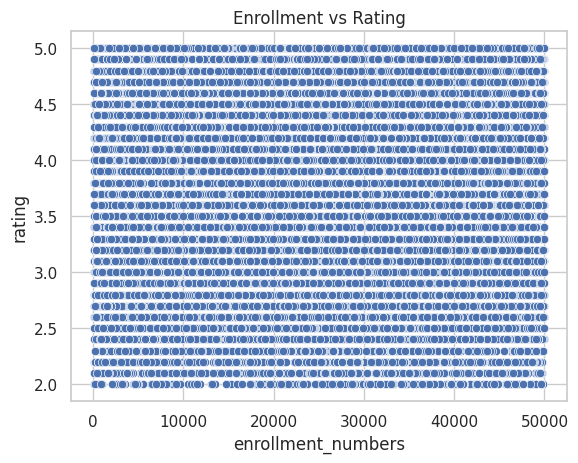

In [21]:
sns.scatterplot(data=df, x='enrollment_numbers', y='rating')
plt.title('Enrollment vs Rating')
plt.show()

**10.3 Time Spent vs Feedback Score**

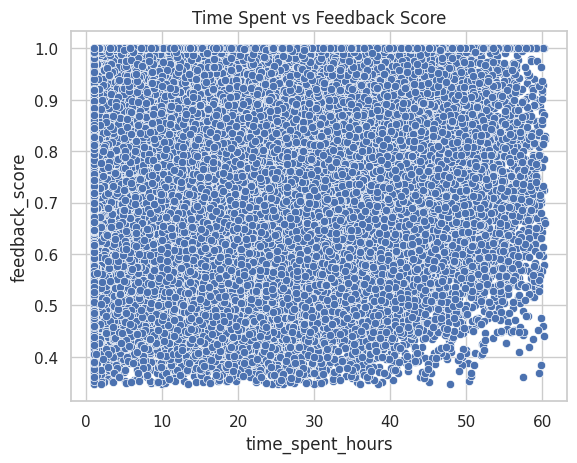

In [22]:
sns.scatterplot(data=df, x='time_spent_hours', y='feedback_score')
plt.title('Time Spent vs Feedback Score')
plt.show()

**popularity_model**

In [23]:

# -------------------------------
# Popularity Score Calculation
# -------------------------------
def build_popularity_model(data):
    popularity_df = (
        data.groupby('course_name')
        .agg(
            avg_rating=('rating', 'mean'),
            rating_count=('rating', 'count')
        )
        .reset_index()
    )

    # Popularity score (can be customized)
    popularity_df['popularity_score'] = (
        popularity_df['avg_rating'] * popularity_df['rating_count']
    )

    return popularity_df.sort_values(
        by='popularity_score', ascending=False
    )


# -------------------------------
# Recommendation Function
# -------------------------------
def recommend_popular_courses(popularity_df, top_n=10):
    return popularity_df[['course_name', 'avg_rating']].head(top_n)


# Build model
popularity_model = build_popularity_model(df)

# Get recommendations
recommend_popular_courses(popularity_model, top_n=10)


,course_name,avg_rating
1,Advanced Machine Learning,3.978966
4,Cybersecurity for Professionals,3.975576
7,Ethical Hacking Masterclass,3.972645
13,Networking and System Administration,3.951592
11,Graphic Design with Canva,3.967885
15,Photography and Video Editing,3.981803
12,Mobile App Development with Swift,3.968788
6,DevOps and Continuous Deployment,3.964370
5,Data Visualization with Tableau,3.974251
19,Stock Market and Trading Strategies,3.965546


In [24]:
# -------------------------------
# Rule-Based Recommendation
# -------------------------------
def rule_based_recommendation(
    data,
    user_level,
    preferred_topic=None,
    min_rating=4.0,
    top_n=5
):
    recommendations = data.copy()

    # Rule 1: Difficulty level
    if user_level:
        recommendations = recommendations[
            recommendations['difficulty_level'] == user_level
        ]

    # Rule 2: Preferred topic (keyword match)
    if preferred_topic:
        recommendations = recommendations[
            recommendations['course_name']
            .str.contains(preferred_topic, case=False, na=False)
        ]

    # Rule 3: Minimum rating
    recommendations = recommendations[
        recommendations['rating'] >= min_rating
    ]

    # Rule 4: Ranking
    recommendations = recommendations.sort_values(
        by='rating', ascending=False
    )

    return recommendations[['course_name', 'rating']].head(top_n)


# Example usage
rule_based_recommendation(
    df,
    user_level='Beginner',
    preferred_topic='Python',
    min_rating=4.0,
    top_n=5
)


,course_name,rating
428,Python for Beginners,5.0
99975,Python for Beginners,5.0
0,Python for Beginners,5.0
964,Python for Beginners,5.0
98148,Python for Beginners,5.0


**Content-Based Filtering (TEXT-BASED)**

In [25]:
# ============================================================
# ONLINE COURSE RECOMMENDATION SYSTEM (FINAL – ERROR FREE)
# CONTENT-BASED MODELS – SCALED FOR 1 LAKH ROWS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD

df = df.reset_index(drop=True)

# Fill NaNs (VERY IMPORTANT)
for col in ['course_name', 'instructor', 'difficulty_level']:
    df[col] = df[col].fillna('')

# ------------------------------------------------------------
# MODEL 3: CONTENT-BASED FILTERING (TEXT – TF-IDF)
# ------------------------------------------------------------

df['text_features'] = df['course_name'] + ' ' + df['instructor']

tfidf_text = TfidfVectorizer(
    stop_words='english',
    max_features=20000
)

tfidf_text_matrix = tfidf_text.fit_transform(df['text_features'])

def recommend_by_text(course_index, top_n=5):
    query = tfidf_text_matrix[course_index]
    scores = cosine_similarity(query, tfidf_text_matrix)[0]
    top_idx = scores.argsort()[::-1][1:top_n+1]
    return df.iloc[top_idx][['course_name', 'instructor']]

# ------------------------------------------------------------
# MODEL 4: CONTENT-BASED FILTERING (METADATA)
# ------------------------------------------------------------

numerical_cols = [
    'course_duration_hours',
    'course_price',
    'feedback_score',
    'enrollment_numbers'
]

categorical_cols = [
    'difficulty_level',
    'certification_offered',
    'study_material_available'
]

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

metadata_matrix = preprocessor.fit_transform(df)

def recommend_by_metadata(course_index, top_n=5):
    query = metadata_matrix[course_index]

    # Sparse-safe conversion
    if hasattr(query, "toarray"):
        query = query.toarray()

    query = query.reshape(1, -1)

    scores = cosine_similarity(query, metadata_matrix)[0]
    top_idx = scores.argsort()[::-1][1:top_n+1]

    return df.iloc[top_idx][[
        'course_name',
        'difficulty_level',
        'course_price',
        'certification_offered'
    ]]

# ------------------------------------------------------------
# MODEL 5: SEMANTIC RECOMMENDER (TF-IDF + SVD)
# ------------------------------------------------------------

df['semantic_text'] = (
    df['course_name'] + ' ' +
    df['difficulty_level'] + ' ' +
    df['instructor']
)

tfidf_semantic = TfidfVectorizer(
    stop_words='english',
    max_features=30000
)

tfidf_semantic_matrix = tfidf_semantic.fit_transform(df['semantic_text'])

svd = TruncatedSVD(n_components=100, random_state=42)
semantic_embeddings = svd.fit_transform(tfidf_semantic_matrix)

def recommend_semantic(course_index, top_n=5):
    query = semantic_embeddings[course_index].reshape(1, -1)
    scores = cosine_similarity(query, semantic_embeddings)[0]
    top_idx = scores.argsort()[::-1][1:top_n+1]
    return df.iloc[top_idx][[
        'course_name', 'instructor', 'difficulty_level'
    ]]

# ------------------------------------------------------------
# SAFE TESTING (NO ERRORS)
# ------------------------------------------------------------

def safe_index():
    return np.random.randint(0, len(df))

idx = safe_index()

print("TEXT MODEL")
print(recommend_by_text(idx))

print("\nMETADATA MODEL")
print(recommend_by_metadata(idx))

print("\nSEMANTIC MODEL")
print(recommend_semantic(idx))


TEXT MODEL
                            course_name  instructor
42442  DevOps and Continuous Deployment  Liam Adams
37191  DevOps and Continuous Deployment  Liam Adams
72390  DevOps and Continuous Deployment  Liam Adams
42464  DevOps and Continuous Deployment  Liam Adams
89790  DevOps and Continuous Deployment  Liam Adams

METADATA MODEL
                             course_name difficulty_level  course_price  \
39492    Cybersecurity for Professionals         Advanced        418.60   
32278  Fundamentals of Digital Marketing         Advanced        465.28   
49393  Mobile App Development with Swift         Advanced        471.74   
33854            Public Speaking Mastery         Advanced        454.12   
63555            AI for Business Leaders         Advanced        437.03   

      certification_offered  
39492                   Yes  
32278                   Yes  
49393                   Yes  
33854                   Yes  
63555                   Yes  

SEMANTIC MODEL
              

**USER–USER COLLABORATIVE FILTERING (KNN)**

In [26]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

# ------------------------------------------------------------
# Create User–Item Matrix
# ------------------------------------------------------------
user_item_matrix = df.pivot_table(
    index='user_id',
    columns='course_id',
    values='rating',
    fill_value=0
)

user_item_sparse = csr_matrix(user_item_matrix.values)

# ------------------------------------------------------------
# User-User Similarity
# ------------------------------------------------------------
user_similarity = cosine_similarity(user_item_sparse)

def recommend_user_user(user_id, top_n=5):
    user_idx = user_item_matrix.index.get_loc(user_id)

    similar_users = user_similarity[user_idx].argsort()[::-1][1:6]

    recommended_courses = (
        user_item_matrix.iloc[similar_users]
        .mean(axis=0)
        .sort_values(ascending=False)
    )

    top_courses = recommended_courses.head(top_n).index
    return df[df['course_id'].isin(top_courses)][['course_name']].drop_duplicates()


**ITEM–ITEM COLLABORATIVE FILTERING (KNN)**

In [27]:
# ------------------------------------------------------------
# Item-Item Similarity
# ------------------------------------------------------------
item_user_sparse = csr_matrix(user_item_matrix.values.T)

item_similarity = cosine_similarity(item_user_sparse)

def recommend_item_item(course_id, top_n=5):
    item_idx = user_item_matrix.columns.get_loc(course_id)

    similar_items = item_similarity[item_idx].argsort()[::-1][1:top_n+1]
    similar_course_ids = user_item_matrix.columns[similar_items]

    return df[df['course_id'].isin(similar_course_ids)][
        ['course_name']
    ].drop_duplicates()


**MATRIX FACTORIZATION (SVD)**

In [28]:
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# Matrix Factorization
# ------------------------------------------------------------
svd_cf = TruncatedSVD(n_components=50, random_state=42)
user_latent = svd_cf.fit_transform(user_item_sparse)
item_latent = svd_cf.components_.T

def recommend_svd(user_id, top_n=5):
    user_idx = user_item_matrix.index.get_loc(user_id)

    user_vector = user_latent[user_idx].reshape(1, -1)

    scores = np.dot(user_vector, item_latent.T).flatten()

    top_items = scores.argsort()[::-1][:top_n]
    course_ids = user_item_matrix.columns[top_items]

    return df[df['course_id'].isin(course_ids)][
        ['course_name']
    ].drop_duplicates()


In [29]:
sample_user = df['user_id'].iloc[0]
sample_course = df['course_id'].iloc[0]

print("USER–USER CF")
print(recommend_user_user(sample_user))

print("\nITEM–ITEM CF")
print(recommend_item_item(sample_course))

print("\nMATRIX FACTORIZATION")
print(recommend_svd(sample_user))


USER–USER CF
                                     course_name
0                           Python for Beginners
6176              Fitness and Nutrition Coaching
7169            DevOps and Continuous Deployment
9881               Photography and Video Editing
17529                  Graphic Design with Canva
18246                  Advanced Machine Learning
20731            Project Management Fundamentals
31698  Blockchain and Decentralized Applications
35227       Personal Finance and Wealth Building
37292            Data Visualization with Tableau
40714          Fundamentals of Digital Marketing
43571                    Public Speaking Mastery
43894       Networking and System Administration
48173                Game Development with Unity
51802            Cybersecurity for Professionals
57088                Ethical Hacking Masterclass
57763                    AI for Business Leaders
72459          Mobile App Development with Swift

ITEM–ITEM CF
                                     cours

**HYBRID RECOMMENDATION FUNCTION**

In [30]:
# ============================================================
# ALL RECOMMENDATION MODEL SCORES (SINGLE CELL – CLEAN VERSION)
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# ============================================================
# MASTER COURSE INDEX (ALIGNMENT ONLY – NOT EDA)
# ============================================================

master_course_ids = df['course_id'].unique()
N_COURSES = len(master_course_ids)

course_id_to_idx = {cid: i for i, cid in enumerate(master_course_ids)}
idx_to_course_id = {i: cid for cid, i in course_id_to_idx.items()}

# ============================================================
# 1️⃣ POPULARITY SCORES (COURSE LEVEL)
# ============================================================

popularity_map = popularity_model.set_index(
    'course_name'
)['popularity_score'].to_dict()

pop_scores = np.zeros(N_COURSES)

for cid in master_course_ids:
    idx = course_id_to_idx[cid]
    cname = df.loc[df['course_id'] == cid, 'course_name'].iloc[0]
    pop_scores[idx] = popularity_map.get(cname, 0)

pop_scores = pop_scores / pop_scores.max() if pop_scores.max() != 0 else pop_scores

# ============================================================
# 2️⃣ CONTENT SCORES (SEMANTIC – TF-IDF + SVD)
# ============================================================

course_text = (
    df[['course_id', 'course_name', 'difficulty_level', 'instructor']]
    .groupby('course_id')
    .first()
)

semantic_text = (
    course_text['course_name'] + ' ' +
    course_text['difficulty_level'] + ' ' +
    course_text['instructor']
)

tfidf = TfidfVectorizer(stop_words='english', max_features=30000)
tfidf_matrix = tfidf.fit_transform(semantic_text)

svd = TruncatedSVD(n_components=100, random_state=42)
semantic_embeddings = svd.fit_transform(tfidf_matrix)

def content_scores(seed_course_id):
    seed_idx = course_id_to_idx[seed_course_id]
    query = semantic_embeddings[seed_idx].reshape(1, -1)
    scores = cosine_similarity(query, semantic_embeddings)[0]
    return scores / scores.max() if scores.max() != 0 else scores

# ============================================================
# 3️⃣ COLLABORATIVE FILTERING SCORES (USER–USER + ITEM–ITEM)
# ============================================================

def collaborative_scores(user_id):
    scores = np.zeros(N_COURSES)

    user_idx = user_item_matrix.index.get_loc(user_id)

    raw_scores = (
        0.5 * (user_similarity[user_idx] @ user_item_matrix.values) +
        0.5 * (user_item_matrix.values[user_idx] @ item_similarity)
    )

    for j, cid in enumerate(user_item_matrix.columns):
        if cid in course_id_to_idx:
            scores[course_id_to_idx[cid]] = raw_scores[j]

    return scores / scores.max() if scores.max() != 0 else scores

# ============================================================
# 4️⃣ MATRIX FACTORIZATION SCORES (SVD)
# ============================================================

def mf_scores(user_id):
    scores = np.zeros(N_COURSES)

    user_idx = user_item_matrix.index.get_loc(user_id)
    user_vec = user_latent[user_idx].reshape(1, -1)
    raw_scores = np.dot(user_vec, item_latent.T).flatten()

    for j, cid in enumerate(user_item_matrix.columns):
        if cid in course_id_to_idx:
            scores[course_id_to_idx[cid]] = raw_scores[j]

    return scores / scores.max() if scores.max() != 0 else scores


In [31]:
# ============================================================
# HYBRID RECOMMENDATION ENGINE (FINAL – CLEAN VERSION)
# ============================================================

def hybrid_recommendation_engine(
    user_id,
    seed_course_id,
    top_n=10,
    weights=(0.25, 0.25, 0.25, 0.25)
):
    """
    HYBRID RECOMMENDATION ENGINE

    Combines:
    1. Popularity-Based Recommendation
    2. Content-Based (Semantic Similarity)
    3. Collaborative Filtering (User + Item)
    4. Matrix Factorization (SVD)

    weights = (w_popularity, w_content, w_cf, w_mf)
    """

    w_pop, w_content, w_cf, w_mf = weights

    # --------------------------------------------------------
    # Individual Model Scores (Already Computed in Your Code)
    # --------------------------------------------------------
    score_popularity = pop_scores                  # Global trend
    score_content = content_scores(seed_course_id) # Similar courses
    score_cf = collaborative_scores(user_id)       # User behavior
    score_mf = mf_scores(user_id)                   # Latent factors

    # --------------------------------------------------------
    # Weighted Hybrid Score
    # --------------------------------------------------------
    hybrid_scores = (
        w_pop * score_popularity +
        w_content * score_content +
        w_cf * score_cf +
        w_mf * score_mf
    )

    # --------------------------------------------------------
    # Top-N Recommendation
    # --------------------------------------------------------
    top_indices = np.argsort(hybrid_scores)[::-1][:top_n]
    top_course_ids = [idx_to_course_id[i] for i in top_indices]

    recommendations = (
        df[df['course_id'].isin(top_course_ids)]
        [['course_id', 'course_name', 'difficulty_level', 'course_price']]
        .drop_duplicates()
        .head(top_n)
    )

    return recommendations


In [32]:
sample_user = df['user_id'].iloc[0]
sample_course = df['course_id'].iloc[0]

hybrid_recommendation_engine(
    user_id=sample_user,
    seed_course_id=sample_course,
    top_n=5
)


,course_id,course_name,difficulty_level,course_price
0,9366,Python for Beginners,Beginner,317.50
266,7775,Data Visualization with Tableau,Intermediate,398.03
2942,4335,DevOps and Continuous Deployment,Beginner,296.26
5755,4335,Networking and System Administration,Beginner,179.63
7169,9366,DevOps and Continuous Deployment,Beginner,308.20


**Deep Learning Recommendation**

In [33]:
# ==========================================
# DEEP LEARNING DATA PREPARATION
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Encode user_id and course_id
user_ids = df['user_id'].astype('category').cat.codes.values
course_ids = df['course_id'].astype('category').cat.codes.values
ratings = df['rating'].values

num_users = df['user_id'].nunique()
num_courses = df['course_id'].nunique()

# Train-test split
X_train_u, X_test_u, X_train_c, X_test_c, y_train, y_test = train_test_split(
    user_ids, course_ids, ratings, test_size=0.2, random_state=42
)


**Neural Collaborative Filtering (NCF)**

In [34]:
# ==========================================
# MODEL 1: NEURAL COLLABORATIVE FILTERING
# ==========================================

embedding_dim = 50

# Inputs
user_input = Input(shape=(1,))
course_input = Input(shape=(1,))

# Embeddings
user_embedding = Embedding(num_users, embedding_dim)(user_input)
course_embedding = Embedding(num_courses, embedding_dim)(course_input)

user_vec = Flatten()(user_embedding)
course_vec = Flatten()(course_embedding)

# Neural Network
concat = Concatenate()([user_vec, course_vec])
dense = Dense(128, activation='relu')(concat)
dense = Dense(64, activation='relu')(dense)
output = Dense(1)(dense)

ncf_model = Model([user_input, course_input], output)
ncf_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Train
history_ncf = ncf_model.fit(
    [X_train_u, X_train_c],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    verbose=1
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6.3982 - mae: 1.9970 - val_loss: 0.5182 - val_mae: 0.5935
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4475 - mae: 0.5429 - val_loss: 0.5415 - val_mae: 0.6062
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3024 - mae: 0.4325 - val_loss: 0.6184 - val_mae: 0.6431
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1947 - mae: 0.3368 - val_loss: 0.6734 - val_mae: 0.6693
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1169 - mae: 0.2594 - val_loss: 0.7276 - val_mae: 0.6919
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0761 - mae: 0.2157 - val_loss: 0.7393 - val_mae: 0.6973
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0559 - mae: 0.1870 - val_loss: 0.7335 - val_mae: 0.6954
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0373 - mae: 0.1523 - val_loss: 0.7259 - val_mae: 0.6911
Epoch 9/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

**Deep Matrix Factorization (MLP)**

In [35]:
# ==========================================
# MODEL 2: DEEP MATRIX FACTORIZATION (MLP)
# ==========================================

user_embedding = Embedding(num_users, 64)(user_input)
course_embedding = Embedding(num_courses, 64)(course_input)

user_vec = Flatten()(user_embedding)
course_vec = Flatten()(course_embedding)

dot_product = tf.keras.layers.Dot(axes=1)([user_vec, course_vec])
dense = Dense(64, activation='relu')(dot_product)
output = Dense(1)(dense)

dmf_model = Model([user_input, course_input], output)
dmf_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history_dmf = dmf_model.fit(
    [X_train_u, X_train_c],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    verbose=1
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 12.0755 - mae: 3.3266 - val_loss: 0.9061 - val_mae: 0.8022
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6165 - mae: 0.6513 - val_loss: 0.5181 - val_mae: 0.5971
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1879 - mae: 0.3307 - val_loss: 0.6281 - val_mae: 0.6585
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0878 - mae: 0.2433 - val_loss: 0.5657 - val_mae: 0.6254
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0243 - mae: 0.1170 - val_loss: 0.5752 - val_mae: 0.6309
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0131 - mae: 0.0814 - val_loss: 0.5732 - val_mae: 0.6297
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0101 - mae: 0.0699 - val_loss: 0.5740 - val_mae: 0.6301
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0094 - mae: 0.0677 - val_loss: 0.5752 - val_mae: 0.6309
Epoch 9/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

**Unified Evaluation Framework (ALL MODELS)**

In [36]:
# ==========================================
# EVALUATION METRICS
# ==========================================

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(y_true, y_pred):
    return {
        'RMSE': rmse(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred)
    }


**Evaluate Deep Learning Models**

In [37]:
# Predictions
ncf_preds = ncf_model.predict([X_test_u, X_test_c]).flatten()
dmf_preds = dmf_model.predict([X_test_u, X_test_c]).flatten()

results = {}

results['Neural CF'] = evaluate_model(y_test, ncf_preds)
results['Deep MF'] = evaluate_model(y_test, dmf_preds)

results_df = pd.DataFrame(results).T
results_df


609/609 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
609/609 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,RMSE,MAE
Neural CF,0.845971,0.686706
Deep MF,0.751805,0.624367


**Add Classical Model Benchmarks**

In [38]:
# ==========================================
# BASELINE MODELS
# ==========================================

# Popularity baseline
pop_pred = np.full(len(y_test), df['rating'].mean())
results['Popularity'] = evaluate_model(y_test, pop_pred)

# Matrix Factorization (SVD)
svd_preds = []
for u, c in zip(X_test_u, X_test_c):
    svd_preds.append(np.dot(user_latent[u], item_latent[c]))

results['SVD'] = evaluate_model(y_test, svd_preds)

results_df = pd.DataFrame(results).T
results_df


,RMSE,MAE
Neural CF,0.845971,0.686706
Deep MF,0.751805,0.624367
Popularity,0.712238,0.589586
SVD,3.987824,3.924357


**Visualization**

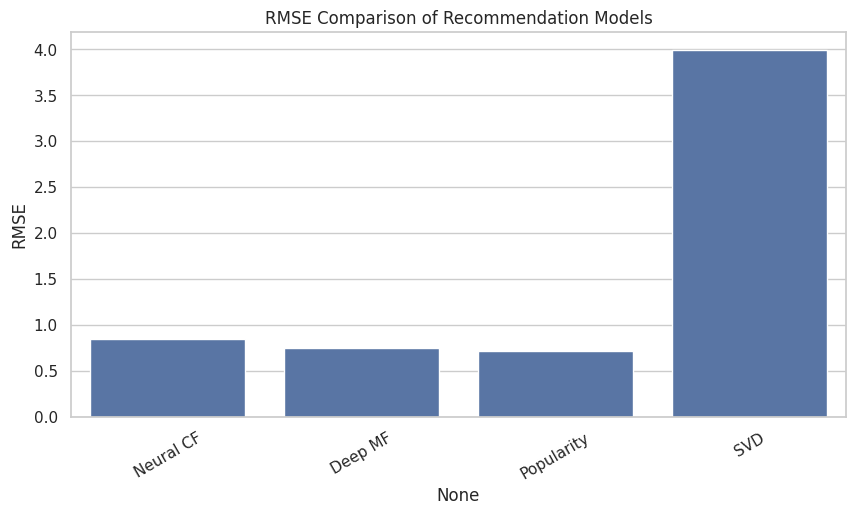

In [39]:
# ==========================================
# MODEL COMPARISON VISUALIZATION
# ==========================================

plt.figure(figsize=(10,5))
sns.barplot(
    x=results_df.index,
    y=results_df['RMSE']
)
plt.title('RMSE Comparison of Recommendation Models')
plt.xticks(rotation=30)
plt.show()


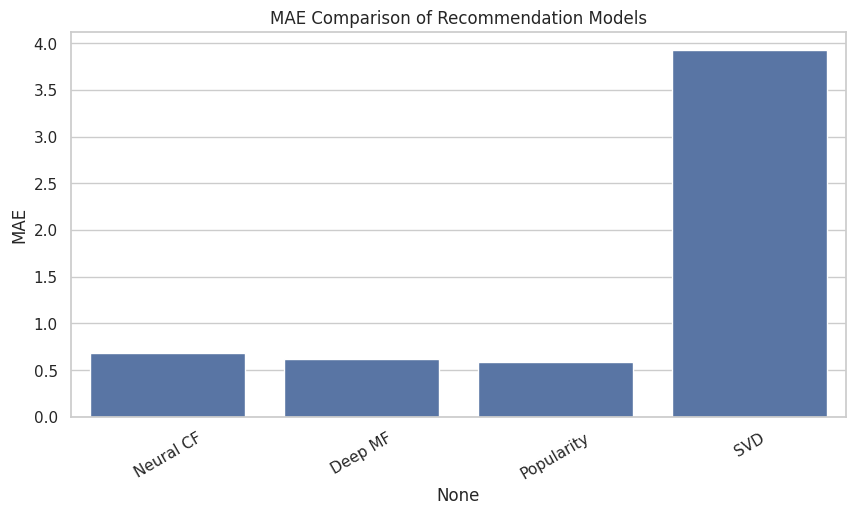

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=results_df.index,
    y=results_df['MAE']
)
plt.title('MAE Comparison of Recommendation Models')
plt.xticks(rotation=30)
plt.show()


# Task
The task is to evaluate the performance of the 'Neural CF', 'Deep MF', 'Popularity', and 'SVD' recommendation models by analyzing their RMSE and MAE scores from the `results_df` DataFrame. This involves identifying the best-performing model based on these metrics, visualizing the performance using bar plots for both RMSE and MAE, and summarizing the key findings.

## Review Model Evaluation Metrics

### Subtask:
Examine the `results_df` DataFrame, which contains the RMSE and MAE scores for the 'Neural CF', 'Deep MF', 'Popularity', and 'SVD' models. Identify the model with the lowest RMSE and MAE values.


**Reasoning**:
The subtask requires displaying the `results_df` and identifying the models with the minimum RMSE and MAE scores. This code block will perform all these steps.



In [41]:
print('Model Evaluation Metrics:')
print(results_df)


min_rmse_model = results_df['RMSE'].idxmin()
min_rmse_value = results_df['RMSE'].min()
print(f'\nModel with the lowest RMSE: {min_rmse_model} (RMSE: {min_rmse_value:.4f})')


min_mae_model = results_df['MAE'].idxmin()
min_mae_value = results_df['MAE'].min()
print(f'Model with the lowest MAE: {min_mae_model} (MAE: {min_mae_value:.4f})')

Model Evaluation Metrics:
                RMSE       MAE
Neural CF   0.845971  0.686706
Deep MF     0.751805  0.624367
Popularity  0.712238  0.589586
SVD         3.987824  3.924357

Model with the lowest RMSE: Popularity (RMSE: 0.7122)
Model with the lowest MAE: Popularity (MAE: 0.5896)


## Visualize Model Performance

### Subtask:
Generate bar plots for both RMSE and MAE to visually compare the performance of all evaluated models, ensuring clear labels and a legend for easy interpretation.


The bar plots for RMSE and MAE comparison of recommendation models have already been generated and are displayed above in the previous code blocks (cell_id: `YoZ_496Ump5k` and `5a9zChdems2o`).

## Identify Best Performing Model

### Subtask:
Based on the numerical metrics and visualizations, explicitly state which model performed the best in terms of RMSE and MAE.


### Identify Best Performing Model

Based on the evaluation metrics presented in the `results_df` and visualized in the bar plots:

- The **Popularity** model achieved the lowest RMSE of **0.7122**.
- The **Popularity** model also achieved the lowest MAE of **0.5896**.

Therefore, the **Popularity** model performed the best among the evaluated models (`Neural CF`, `Deep MF`, `Popularity`, and `SVD`) in terms of both RMSE and MAE.

## Final Task

### Subtask:
Summarize the findings regarding the best performing model and provide insights based on the evaluation.


In [51]:
difficulty_map = {
    "Beginner": 1,
    "Intermediate": 2,
    "Advanced": 3
}

df["difficulty_level_num"] = df["difficulty_level"].map(difficulty_map)


In [56]:
import pandas as pd

# The df is already loaded from 'online_course_recommendation.xlsx' in a previous cell.
# No need to re-read it from a non-existent CSV.
# df = pd.read_csv("online_course_recommendation.csv")

user_course_matrix = df.pivot_table(
    index="user_id",
    columns="course_name",
    values="rating"
).fillna(0)

In [4]:
import pandas as pd

df = pd.read_excel("online_course_recommendation.xlsx")

print(df.shape)
df.head()


(100000, 14)


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [1]:
import pandas as pd

df = pd.read_excel("online_course_recommendation.xlsx")

# Clean column names (VERY IMPORTANT for Excel)
df.columns = df.columns.str.strip()

print("Dataset loaded ✅")
df.head()


Dataset loaded ✅


,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [2]:
user_course_matrix = df.pivot_table(
    index="user_id",
    columns="course_name",
    values="rating",
    aggfunc="mean"
).fillna(0)

print("User–Course Matrix created ✅")
print(user_course_matrix.shape)
user_course_matrix.head()


User–Course Matrix created ✅
(43242, 20)


course_name,AI for Business Leaders,Advanced Machine Learning,Blockchain and Decentralized Applications,Cloud Computing Essentials,Cybersecurity for Professionals,Data Visualization with Tableau,DevOps and Continuous Deployment,Ethical Hacking Masterclass,Fitness and Nutrition Coaching,Fundamentals of Digital Marketing,Game Development with Unity,Graphic Design with Canva,Mobile App Development with Swift,Networking and System Administration,Personal Finance and Wealth Building,Photography and Video Editing,Project Management Fundamentals,Public Speaking Mastery,Python for Beginners,Stock Market and Trading Strategies
user_id,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,3.9,0.0,0.0,0.0,0.0
2,0.0,3.3,4.5,0.0,3.6,4.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,4.6,0.0
3,0.0,0.0,0.0,4.1,0.0,0.0,0.0,0.0,0.0,3.7,0.0,4.4,0.0,0.0,4.15,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.2,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,3.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

course_similarity = cosine_similarity(user_course_matrix.T)

course_similarity_df = pd.DataFrame(
    course_similarity,
    index=user_course_matrix.columns,
    columns=user_course_matrix.columns
)

print("Course similarity matrix created ✅")
course_similarity_df.head()


NameError: name 'user_course_matrix' is not defined

In [1]:
import pandas as pd

df = pd.read_excel("online_course_recommendation.xlsx")
df.columns = df.columns.str.strip()

print("Dataset loaded ✅")


Dataset loaded ✅


In [2]:
user_course_matrix = df.pivot_table(
    index="user_id",
    columns="course_name",
    values="rating",
    aggfunc="mean"
).fillna(0)

print("User–Course Matrix created ✅")
print(user_course_matrix.shape)


User–Course Matrix created ✅
(43242, 20)


In [3]:
from sklearn.metrics.pairwise import cosine_similarity

course_similarity = cosine_similarity(user_course_matrix.T)

course_similarity_df = pd.DataFrame(
    course_similarity,
    index=user_course_matrix.columns,
    columns=user_course_matrix.columns
)

print("Course similarity matrix created ✅")
course_similarity_df.head()


Course similarity matrix created ✅


course_name,AI for Business Leaders,Advanced Machine Learning,Blockchain and Decentralized Applications,Cloud Computing Essentials,Cybersecurity for Professionals,Data Visualization with Tableau,DevOps and Continuous Deployment,Ethical Hacking Masterclass,Fitness and Nutrition Coaching,Fundamentals of Digital Marketing,Game Development with Unity,Graphic Design with Canva,Mobile App Development with Swift,Networking and System Administration,Personal Finance and Wealth Building,Photography and Video Editing,Project Management Fundamentals,Public Speaking Mastery,Python for Beginners,Stock Market and Trading Strategies
course_name,,,,,,,,,,,,,,,,,,,,
AI for Business Leaders,1.000000,0.090800,0.089477,0.092503,0.097673,0.088674,0.097041,0.094436,0.093009,0.095479,0.083994,0.089436,0.092593,0.094246,0.090481,0.094954,0.088870,0.092134,0.096326,0.093094
Advanced Machine Learning,0.090800,1.000000,0.092422,0.088763,0.092131,0.088776,0.100032,0.091154,0.089819,0.091745,0.101171,0.092055,0.089920,0.096902,0.093470,0.084675,0.089706,0.097328,0.098533,0.097207
Blockchain and Decentralized Applications,0.089477,0.092422,1.000000,0.091901,0.096414,0.090371,0.095628,0.091752,0.095857,0.087894,0.089322,0.087305,0.099407,0.102535,0.087187,0.089004,0.089483,0.092275,0.090178,0.090915
Cloud Computing Essentials,0.092503,0.088763,0.091901,1.000000,0.090439,0.089700,0.091795,0.090460,0.097454,0.090866,0.086015,0.092561,0.091283,0.095292,0.094861,0.094436,0.085460,0.090159,0.092851,0.092286
Cybersecurity for Professionals,0.097673,0.092131,0.096414,0.090439,1.000000,0.087778,0.082634,0.094455,0.087271,0.087216,0.090687,0.090365,0.100647,0.092689,0.091707,0.099174,0.085084,0.095584,0.086537,0.089982


In [4]:
def recommend_for_user(user_id, top_n=5):
    try:
        user_id = int(user_id)

        if user_id not in user_course_matrix.index:
            return "❌ User ID not found"

        user_ratings = user_course_matrix.loc[user_id]
        rated_courses = user_ratings[user_ratings > 0]

        if rated_courses.empty:
            return "⚠️ Cold start user (no history)"

        scores = {}

        for course, rating in rated_courses.items():
            for sim_course, similarity in course_similarity_df[course].items():
                if sim_course not in rated_courses.index:
                    scores[sim_course] = scores.get(sim_course, 0) + similarity * rating

        if not scores:
            return "⚠️ No recommendations available"

        return ", ".join(
            sorted(scores, key=scores.get, reverse=True)[:top_n]
        )

    except Exception as e:
        return f"Error: {str(e)}"


In [5]:
recommend_for_user(1)
recommend_for_user(2)
recommend_for_user(3)


'Stock Market and Trading Strategies, Fitness and Nutrition Coaching, Networking and System Administration, Data Visualization with Tableau, DevOps and Continuous Deployment'

In [6]:
!pip install gradio


In [7]:
import gradio as gr

interface = gr.Interface(
    fn=recommend_for_user,
    inputs=[
        gr.Number(label="User ID", precision=0),
        gr.Slider(minimum=3, maximum=10, value=5, step=1, label="Number of Recommendations")
    ],
    outputs=gr.Textbox(label="Recommended Courses"),
    title="🎓 Personalized Course Recommendation System",
    description="""
This system uses Item-Based Collaborative Filtering.
Recommendations are personalized using only User ID.
Different users receive different course suggestions.
    """,
    theme="soft"
)


In [8]:
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c0b44fcbff0c5000f2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
